# Demo: How a Deep CNN Produces Image Embeddings

**USF — AI Mobility Class **  
**Hao Zhou** · [haozhou1@usf.edu](mailto:haozhou1@usf.edu)

## Purpose of this notebook

In this notebook, you will see — concretely, on real images — how a deep convolutional neural network (CNN) turns a raw photograph into a **fixed-length numerical vector** (an "embedding") that captures the *semantic content* of the image. By the end of the demo, you'll see that semantically similar images (two stop signs, two cars, etc.) end up close together in this vector space, even though the network was never explicitly told what makes them similar.

This idea — using a deep network as a **general-purpose visual feature extractor** — is the foundation of essentially every modern image-based AI mobility system:

- **Transfer learning** for road-scene tasks (pothole detection, hazard classification, sign recognition) where you have only a few hundred labeled images and can't afford to train a network from scratch.
- **Image retrieval** systems that search dashcam archives for "all frames similar to this one" without any extra labels.
- **Anomaly detection** in driving footage — anything whose embedding lies far from the "normal driving" cluster is automatically flagged for human review.
- **Vision-language models** (CLIP, SigLIP, multi-modal LLMs that you've heard about in the news) — all of these build on top of dense image features just like the ones we extract today.

## The connection to Word2Vec

You've already seen this pattern in our Word2Vec lecture: a network was trained on a *pretext task* (predict nearby words from a center word) and as a side-effect produced word vectors where `king − man + woman ≈ queen`. The network was never told what those analogies meant — geometry just *emerged* from learning to do the pretext task well.

Today we apply the same idea to images:

| Word2Vec (text) | Today's demo (images) |
|---|---|
| Pretext task: predict surrounding words | Pretext task: classify into 1,000 ImageNet categories |
| Output: 300-dim vector per word | Output: 2,048-dim vector per image |
| "Geometry": similar words cluster | "Geometry": similar images cluster |
| Useful for: search, sentiment, NER | Useful for: retrieval, hazard detection, transfer learning |

The mechanics differ (convolution and pooling instead of skip-gram), but the punchline is identical: **the pretext task is just the scaffold; the embedding is the prize.**

## What is an "embedding," really?

An embedding is just a list of numbers — in our case, 2,048 numbers per image. What makes it useful is not the numbers themselves but the **geometry of the space they live in**: images that mean similar things end up at nearby points; images that mean different things end up far apart. We will literally measure this geometry today using cosine similarity, and we will visualize it in 2D using PCA and t-SNE.

## What you'll do, step by step

1. Load a deep CNN pretrained on ImageNet (ResNet-50, ~25 million parameters).
2. Push real traffic-relevant images through it and read its top-3 classification predictions to confirm the model works.
3. Visualize the **feature maps** at each conv stage (`layer1` → `layer4`) to see how the network builds up from edges → textures → parts → whole-object concepts.
4. Extract the **2,048-dim embedding** from the penultimate layer (`avgpool`) for every image.
5. Compute **cosine similarities** between embeddings and verify that semantically similar images cluster — **even though the network was *only* trained on ImageNet labels and was never told that, e.g., a sedan and a pickup truck are "both vehicles."**
6. Project the embedding space to 2D (PCA + t-SNE) so you can *see* the semantic structure with your own eyes.
7. Drop in a brand-new image (e.g., a pothole photo) and see which of the demo images it lands closest to — a tiny but real demo of image retrieval.

## Prerequisites

You should be comfortable with:

- Basic PyTorch usage — tensors, `model(x)`, `with torch.no_grad():`. We are *using* a pretrained model, not training one.
- The intuition that a CNN is a stack of convolutional layers that progressively transform pixels into higher-level features. (We'll see this directly today.)
- The Word2Vec lecture from earlier in the course — we will lean on the parallel.

If you've never seen PyTorch before, you can still follow along — every cell is heavily commented and the figures speak for themselves.

## How to use this notebook

Run the cells top-to-bottom. Most cells produce a figure or a print-out you should pause and read. The discussion questions at the end (Section 10) are designed for in-class conversation — think about them as you go, not just at the end.

> **Big idea, in one sentence:** A classification CNN's penultimate layer is a powerful, general-purpose image encoder, and the geometry of its embedding space corresponds to semantic similarity — even for categories the network was never trained on. *That* is why pretrained networks transfer so well to new mobility tasks.

**Runtime:** CPU is fine — the whole notebook runs in 1–2 minutes on a laptop. A GPU is faster but unnecessary for this demo.

## 1. Setup

If any of these packages are missing, uncomment the install line below.


In [53]:
# !pip install torch torchvision pillow matplotlib scikit-learn requests numpy


In [54]:
import io
import requests
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

torch.manual_seed(42)
np.random.seed(42)

# Check for available devices
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'MPS available: {torch.backends.mps.is_available()}')

Using device: mps
PyTorch version: 2.11.0
MPS available: True


## 2. Load a Pretrained ResNet-50

ResNet-50 is a 50-layer CNN trained by Microsoft Research (He et al., 2015) on **ImageNet** — 1.2 million labeled images across 1,000 categories. The weights ship with `torchvision`.

Note the architecture: a stack of `conv1 → layer1 → layer2 → layer3 → layer4 → avgpool → fc`. The `fc` layer is the 1,000-class softmax — the *pretext* output. The output of `avgpool` is the **2,048-dim embedding** we actually want.


In [55]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.eval().to(device)

# ImageNet class labels for interpreting predictions
imagenet_classes = weights.meta['categories']

n_params = sum(p.numel() for p in model.parameters())
print(f'Model: ResNet-50')
print(f'Number of parameters: {n_params:,}')
print(f'Number of ImageNet classes: {len(imagenet_classes)}')
print()
print('Top-level architecture:')
for name, module in model.named_children():
    print(f'  {name:10s} {type(module).__name__}')


Model: ResNet-50
Number of parameters: 25,557,032
Number of ImageNet classes: 1000

Top-level architecture:
  conv1      Conv2d
  bn1        BatchNorm2d
  relu       ReLU
  maxpool    MaxPool2d
  layer1     Sequential
  layer2     Sequential
  layer3     Sequential
  layer4     Sequential
  avgpool    AdaptiveAvgPool2d
  fc         Linear


## 3. Get Sample Images

We download a small set of public-domain images covering several mobility categories, plus two **distractors** (a cat and a pizza) so we can verify that semantically *unrelated* objects land *far* from traffic objects in embedding space.

If a download fails for any image, the cell will note it and continue. You can also point the URLs at your own dashcam frames.


In [40]:
# We resolve image URLs through the Commons API (the supported entry point for
# scripted access) rather than hard-coding /thumb/ paths. Wikimedia blocks the
# latter and requires a User-Agent that identifies the requester (see the UA
# policy). Update the contact info if you reuse this notebook in another course.

UA = 'USF-AIMobility-Educational/1.0 (haozhou1@usf.edu)'
headers = {'User-Agent': UA}

SAMPLE_FILES = {
    'stop_sign_1':   'Stop sign us.jpg',
    'stop_sign_2':   'STOP sign.jpg',
    'traffic_light': 'Traffic light in Kumasi.jpg',
    'sedan':         '2019 Toyota Corolla Icon Tech VVT-i Hybrid 1.8.jpg',
    'pickup_truck':  'Ford Maverick (pickup truck) IMG 6586.jpg',
    'school_bus':    'Yellow School Bus - geograph.org.uk - 4447138.jpg',
    'bicycle':       'Left side of Flying Pigeon.jpg',
    'pedestrian':    'Walking Women on Bourbon Street Sidewalk, New Orleans, September 2014.jpg',
    'cat':           'Cat November 2010-1a.jpg',
    'pizza':         'Eq it-na pizza-margherita sep2005 sml.jpg',
}

def commons_thumb_url(filename, width=640):
    """Ask the Commons API for a thumbnail URL of the given file."""
    api = 'https://commons.wikimedia.org/w/api.php'
    params = {
        'action': 'query',
        'titles': 'File:' + filename,
        'prop': 'imageinfo',
        'iiprop': 'url',
        'iiurlwidth': width,
        'format': 'json',
    }
    r = requests.get(api, params=params, headers=headers, timeout=15)
    r.raise_for_status()
    page = next(iter(r.json()['query']['pages'].values()))
    if 'missing' in page:
        raise FileNotFoundError(f'Commons file not found: {filename}')
    return page['imageinfo'][0]['thumburl']

images = {}
for name, fn in SAMPLE_FILES.items():
    try:
        url = commons_thumb_url(fn)
        r = requests.get(url, timeout=20, headers=headers)
        r.raise_for_status()
        img = Image.open(io.BytesIO(r.content)).convert('RGB')
        images[name] = img
        print(f'  OK  {name:14s} {img.size}')
    except Exception as e:
        print(f'  --  {name:14s} download failed: {e}')

print(f'\nLoaded {len(images)} images.')


  OK  stop_sign_1    (788, 788)
  OK  stop_sign_2    (960, 1037)
  OK  traffic_light  (960, 720)
  OK  sedan          (960, 505)
  OK  pickup_truck   (960, 639)
  OK  school_bus     (960, 960)
  OK  bicycle        (960, 640)
  OK  pedestrian     (960, 638)
  OK  cat            (960, 1282)
  OK  pizza          (960, 720)

Loaded 10 images.


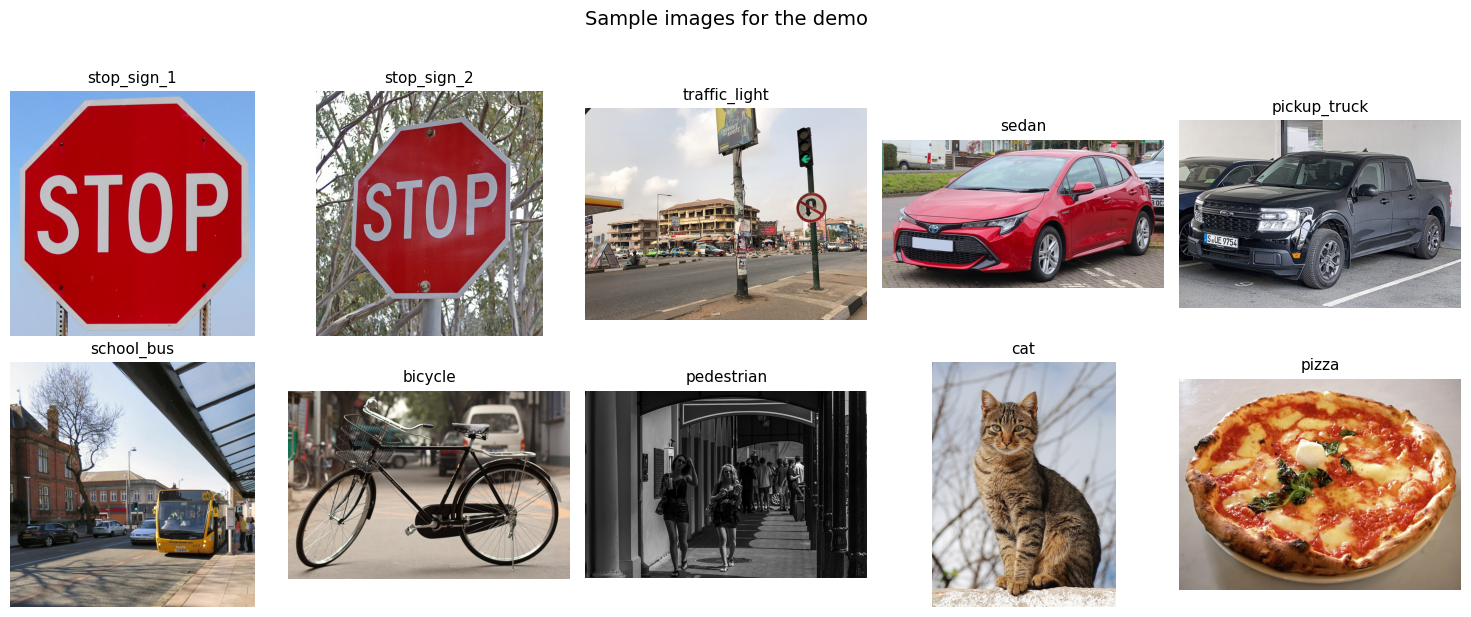

In [41]:
# Display thumbnail grid
n = len(images)
if n == 0:
    print('No images loaded — nothing to display.')
else:
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows), squeeze=False)
    for ax, (name, img) in zip(axes.flat, images.items()):
        ax.imshow(img)
        ax.set_title(name, fontsize=11)
        ax.axis('off')
    for ax in axes.flat[n:]:
        ax.axis('off')
    plt.suptitle('Sample images for the demo', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()



## 4. Preprocess and Classify

Standard ImageNet preprocessing: resize so the short side is 256, center-crop to 224×224, convert to a tensor in [0,1], then normalize per channel using ImageNet's mean and standard deviation.

We then run each image through the **full** network (including the final classification layer) just to confirm the model is working and to read its top-3 predictions.


In [42]:
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Build a batch tensor [N, 3, 224, 224]
names = list(images.keys())
batch = torch.stack([preprocess(images[n]) for n in names]).to(device)
print(f'Batch tensor shape: {tuple(batch.shape)}')


Batch tensor shape: (10, 3, 224, 224)


In [43]:
# Forward pass through the full network
with torch.no_grad():
    logits = model(batch)         # [N, 1000]
    probs = torch.softmax(logits, dim=1)

# Print top-3 predictions per image
topk = torch.topk(probs, k=3, dim=1)
print(f"{'image':14s}  top-3 ImageNet predictions (with probability)")
print('-' * 80)
for i, name in enumerate(names):
    preds = []
    for p, idx in zip(topk.values[i], topk.indices[i]):
        preds.append(f'{imagenet_classes[idx]} ({p.item():.2f})')
    print(f'{name:14s}  {"  |  ".join(preds)}')


image           top-3 ImageNet predictions (with probability)
--------------------------------------------------------------------------------
stop_sign_1     street sign (0.61)  |  traffic light (0.00)  |  chainlink fence (0.00)
stop_sign_2     street sign (0.21)  |  chainlink fence (0.01)  |  worm fence (0.01)
traffic_light   traffic light (0.33)  |  street sign (0.12)  |  parking meter (0.05)
sedan           minivan (0.28)  |  sports car (0.07)  |  grille (0.06)
pickup_truck    minivan (0.14)  |  beach wagon (0.07)  |  car wheel (0.03)
school_bus      passenger car (0.11)  |  minibus (0.08)  |  school bus (0.07)
bicycle         tricycle (0.43)  |  bicycle-built-for-two (0.13)  |  jinrikisha (0.08)
pedestrian      miniskirt (0.31)  |  bubble (0.06)  |  sunglass (0.02)
cat             tiger cat (0.21)  |  tabby (0.14)  |  Egyptian cat (0.10)
pizza           pizza (0.65)  |  broccoli (0.00)  |  potpie (0.00)


**What you should see:** the network correctly identifies the traffic objects (`street sign`, `traffic light`, `pickup`, `school bus`, `mountain bike`, etc.) and the distractors (`tabby cat`, `pizza`). It might mis-label some — note that ImageNet doesn't have a `pedestrian` class, so the walking-man image will get assigned to the closest available label like `umbrella` or `trench coat`. **That's fine for our purposes** — what we care about is the *embedding*, not the final label.


## 5. Visualize the Feature Maps at Each Conv Stage

Now the interesting part. We register **forward hooks** on the four main conv blocks (`layer1`, `layer2`, `layer3`, `layer4`) so we can capture the activations as an image flows through the network.

- `layer1` is shallow → expect to see edges and color blobs.
- `layer2` and `layer3` are intermediate → expect textures and parts.
- `layer4` is deep → expect highly abstract, sparse activations responding to whole-object structure.


In [44]:
# Register forward hooks to capture feature maps
activations = {}
def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

hooks = []
for layer_name in ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']:
    h = getattr(model, layer_name).register_forward_hook(make_hook(layer_name))
    hooks.append(h)

# Pick one image to visualize through the layers
demo_name = 'stop_sign_1' if 'stop_sign_1' in images else names[0]
demo_tensor = preprocess(images[demo_name]).unsqueeze(0).to(device)

with torch.no_grad():
    _ = model(demo_tensor)

for layer_name in ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']:
    print(f'  {layer_name:8s} activation shape: {tuple(activations[layer_name].shape)}')


  layer1   activation shape: (1, 256, 56, 56)
  layer2   activation shape: (1, 512, 28, 28)
  layer3   activation shape: (1, 1024, 14, 14)
  layer4   activation shape: (1, 2048, 7, 7)
  avgpool  activation shape: (1, 2048, 1, 1)


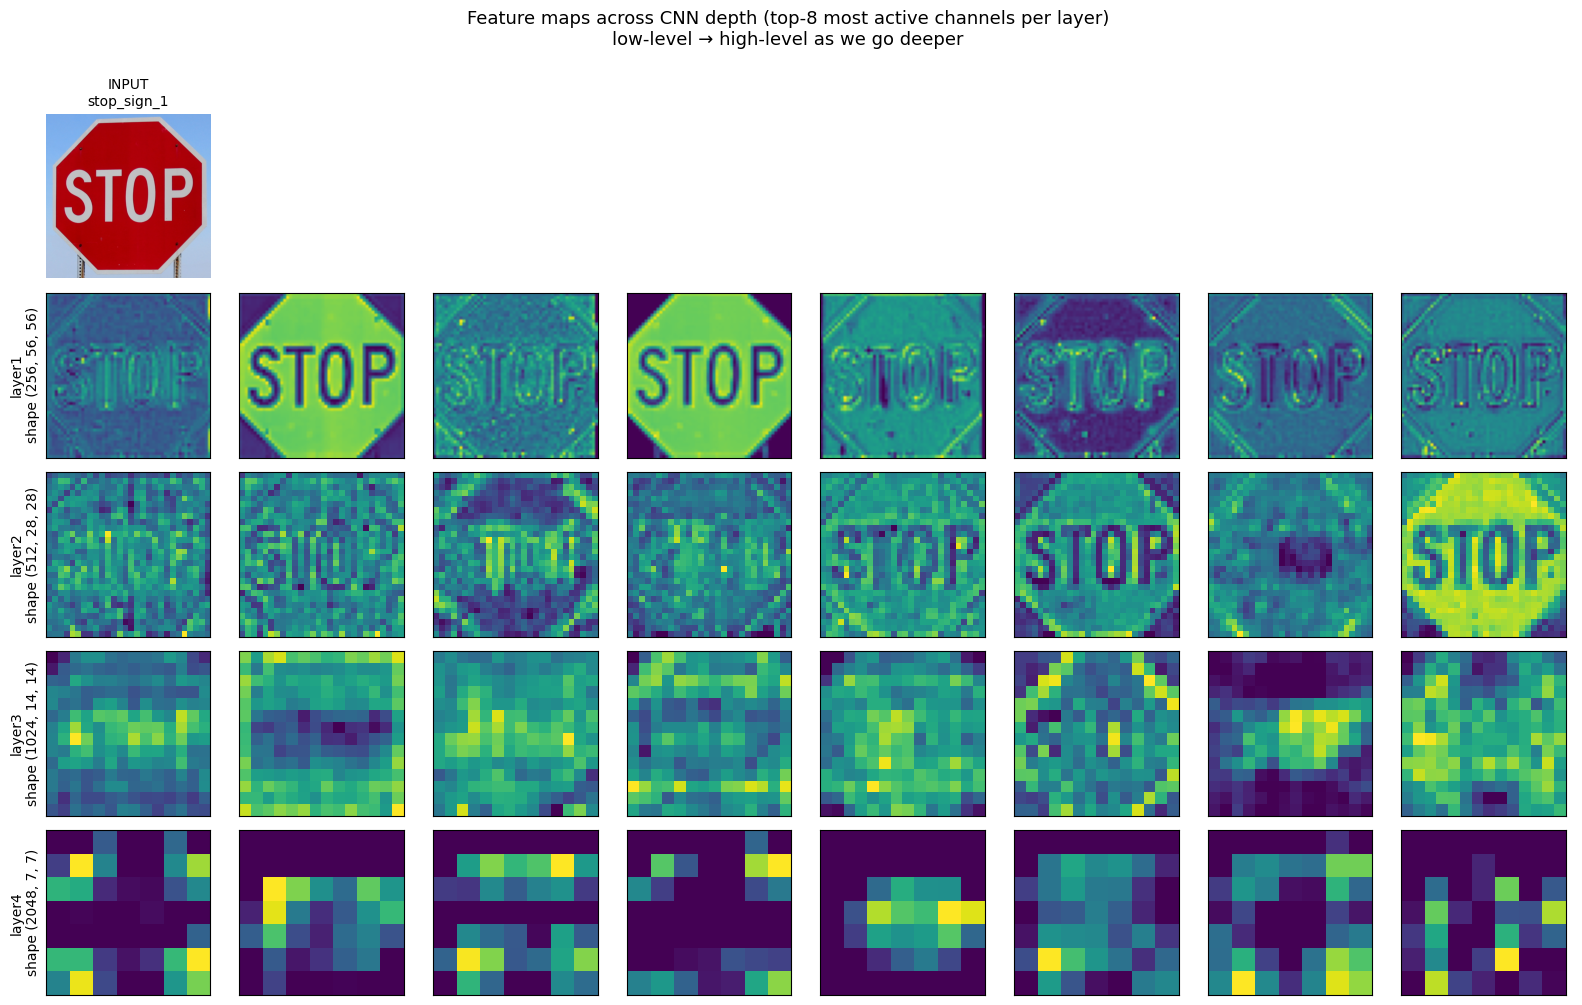

In [45]:
# Visualize 8 channels from each conv block for the demo image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 8, figsize=(16, 10))

# Row 0: original image
axes[0, 0].imshow(images[demo_name])
axes[0, 0].set_title(f'INPUT\n{demo_name}', fontsize=10)
for j in range(1, 8):
    axes[0, j].axis('off')
axes[0, 0].axis('off')

# Rows 1-4: feature maps from layer1..layer4
for row, layer_name in enumerate(['layer1', 'layer2', 'layer3', 'layer4'], start=1):
    feat = activations[layer_name][0]   # [C, H, W]
    n_show = 8
    # Pick channels with the highest mean activation (most informative for this image)
    top_channels = feat.mean(dim=(1, 2)).topk(n_show).indices
    for j, ch in enumerate(top_channels):
        axes[row, j].imshow(feat[ch].numpy(), cmap='viridis')
        if j == 0:
            axes[row, j].set_ylabel(f'{layer_name}\nshape {tuple(feat.shape)}', fontsize=10)
        axes[row, j].set_xticks([])
        axes[row, j].set_yticks([])

plt.suptitle(f'Feature maps across CNN depth (top-8 most active channels per layer)\n'
             f'low-level → high-level as we go deeper', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


**Read the figure carefully:**

- `layer1` activations look almost like edge-detector outputs — they highlight the silhouette of the sign.
- `layer2` and `layer3` activations look more like texture and part detectors — patches lighting up on specific regions of the sign.
- `layer4` activations are sparse, abstract, and spatially small (only 7×7) — each channel represents a high-level concept and fires for whole-object features.

This is the classic **hierarchy of visual features** that classification CNNs learn. Try running the cell again with a different image (e.g., `demo_name = 'sedan'`) and compare which channels light up — different objects activate different deep channels.


## 6. Extract the Penultimate-Layer Embeddings

Now we do the thing this whole notebook is about: capture the output of `avgpool` for every image. That gives us a **2,048-dim vector per image** — the embedding.


In [46]:
# Run all images through the network and grab avgpool output
embeddings = []
with torch.no_grad():
    for n in names:
        x = preprocess(images[n]).unsqueeze(0).to(device)
        _ = model(x)
        emb = activations['avgpool'].squeeze().numpy()   # shape [2048]
        embeddings.append(emb)

embeddings = np.stack(embeddings)      # [N, 2048]
print(f'Embedding matrix shape: {embeddings.shape}')
print()
print(f'First 12 dimensions of "{names[0]}" embedding:')
print(np.round(embeddings[0, :12], 3))

# Clean up the hooks now that we are done with them
for h in hooks:
    h.remove()


Embedding matrix shape: (10, 2048)

First 12 dimensions of "stop_sign_1" embedding:
[0.    0.    0.    0.    0.137 0.005 0.    0.    0.    0.    0.185 0.   ]


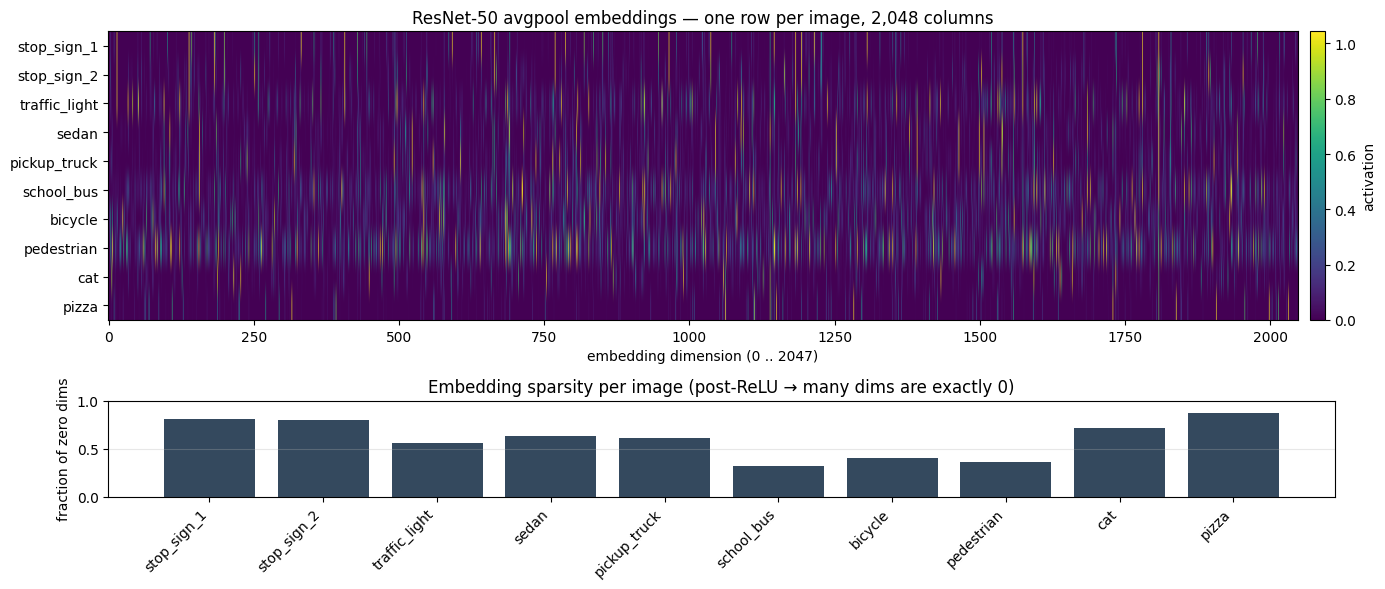

Mean sparsity across images: 60.6%
Mean L2 norm of embeddings:  10.75
Value range: [0.000, 7.062]


In [47]:
# Visualize the raw embedding matrix: one row per image, 2,048 columns.
# This is literally "what an embedding looks like" — before we measure
# similarity (§7) or project to 2D (§8), just stare at the numbers.

fig, axes = plt.subplots(2, 1, figsize=(14, 6),
                         gridspec_kw={'height_ratios': [3, 1]})

# Top: heatmap of the full [N, 2048] embedding matrix
ax = axes[0]
im = ax.imshow(embeddings, aspect='auto', cmap='viridis',
               vmin=0, vmax=np.percentile(embeddings, 99))
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('embedding dimension (0 .. 2047)')
ax.set_title('ResNet-50 avgpool embeddings — one row per image, 2,048 columns')
plt.colorbar(im, ax=ax, label='activation', fraction=0.02, pad=0.01)

# Bottom: per-image sparsity (fraction of dims that are exactly zero).
# avgpool sits right after a ReLU, so most coordinates are dead for any
# given image — the "active" subset is what carries the semantics.
ax = axes[1]
sparsity = (embeddings == 0).mean(axis=1)
ax.bar(range(len(names)), sparsity, color='#34495e')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('fraction of zero dims')
ax.set_ylim(0, 1)
ax.set_title('Embedding sparsity per image (post-ReLU → many dims are exactly 0)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean sparsity across images: {sparsity.mean():.1%}')
print(f'Mean L2 norm of embeddings:  {np.linalg.norm(embeddings, axis=1).mean():.2f}')
print(f'Value range: [{embeddings.min():.3f}, {embeddings.max():.3f}]')


## 7. How Similar Are These Embeddings to Each Other?

We compute the pairwise **cosine similarity** between every pair of embeddings. Cosine similarity = 1.0 means identical direction (very similar); 0.0 means orthogonal; negative means opposing.

**Predictions before we look at the heatmap:**
- Stop-sign-1 and Stop-sign-2 should be highly similar (different photos of the same kind of object).
- Sedan, pickup truck, school bus should form a vehicle cluster.
- Cat and pizza should be far from everything traffic-related.


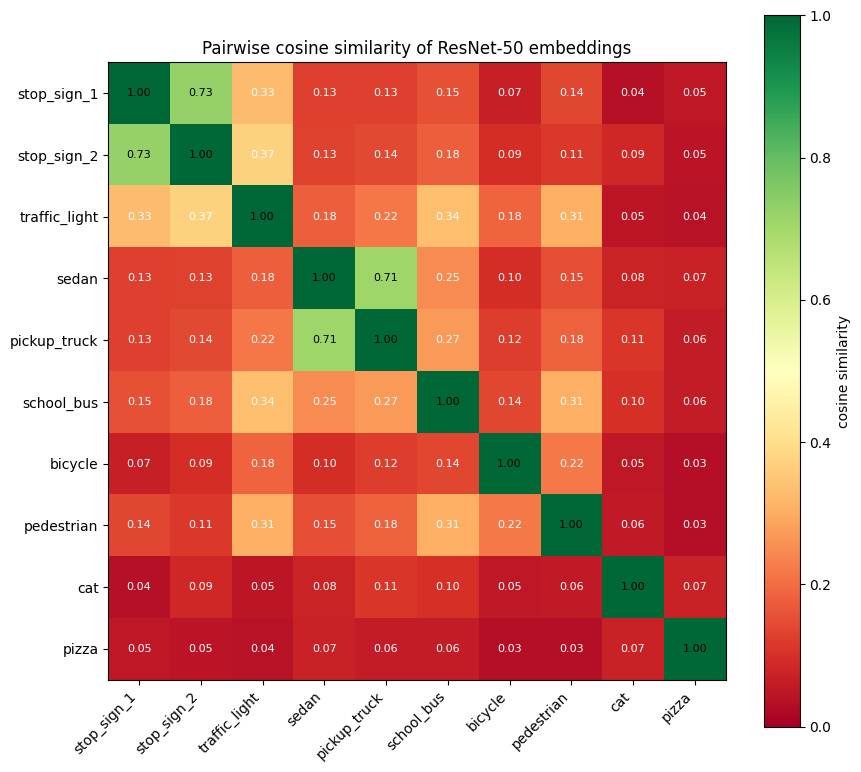

In [48]:
sim = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sim, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticklabels(names)

# Overlay the numeric similarity values
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                color='black' if sim[i, j] > 0.5 else 'white', fontsize=8)

plt.colorbar(im, ax=ax, label='cosine similarity')
ax.set_title('Pairwise cosine similarity of ResNet-50 embeddings', fontsize=12)
plt.tight_layout()
plt.show()


In [49]:
# Most-similar pair for each image (excluding itself)
print('Nearest neighbor for each image (by cosine similarity):')
print('-' * 60)
for i, n in enumerate(names):
    s = sim[i].copy()
    s[i] = -1   # exclude self
    nn = np.argmax(s)
    print(f'  {n:14s}  ->  {names[nn]:14s}  (similarity {s[nn]:.3f})')


Nearest neighbor for each image (by cosine similarity):
------------------------------------------------------------
  stop_sign_1     ->  stop_sign_2     (similarity 0.726)
  stop_sign_2     ->  stop_sign_1     (similarity 0.726)
  traffic_light   ->  stop_sign_2     (similarity 0.372)
  sedan           ->  pickup_truck    (similarity 0.708)
  pickup_truck    ->  sedan           (similarity 0.708)
  school_bus      ->  traffic_light   (similarity 0.335)
  bicycle         ->  pedestrian      (similarity 0.221)
  pedestrian      ->  traffic_light   (similarity 0.308)
  cat             ->  pickup_truck    (similarity 0.110)
  pizza           ->  cat             (similarity 0.073)


**This is the key result.** Notice how:

- Stop signs find each other as nearest neighbors.
- Vehicles cluster with other vehicles.
- The cat and pizza land in their own corner of the space, far from everything traffic.

**The network was never trained to know that a sedan and a pickup truck are 'both vehicles'** — it was trained on 1,000-way classification. The clustering you see is *emergent* — a side effect of the network needing useful internal features. This is exactly why these embeddings transfer to new tasks (pothole detection, hazard detection, anomaly detection on dashcam footage) that the network was never trained on.


## 8. Project the 2,048-D Embedding Space to 2D

Cosine-similarity heatmaps are useful but hard to scan. Let's reduce the 2,048-dim embeddings to 2-D using **PCA** (linear, fast, deterministic) and **t-SNE** (nonlinear, preserves local neighborhoods) and see the cluster structure visually.


In [50]:
# PCA to 2D
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%} '
      f'({pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%})')

# t-SNE to 2D
perp = max(2, min(5, len(embeddings) - 1))
tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
emb_tsne = tsne.fit_transform(embeddings)
print(f't-SNE done with perplexity={perp}.')


PCA explained variance: 40.3% (22.5% + 17.8%)
t-SNE done with perplexity=5.


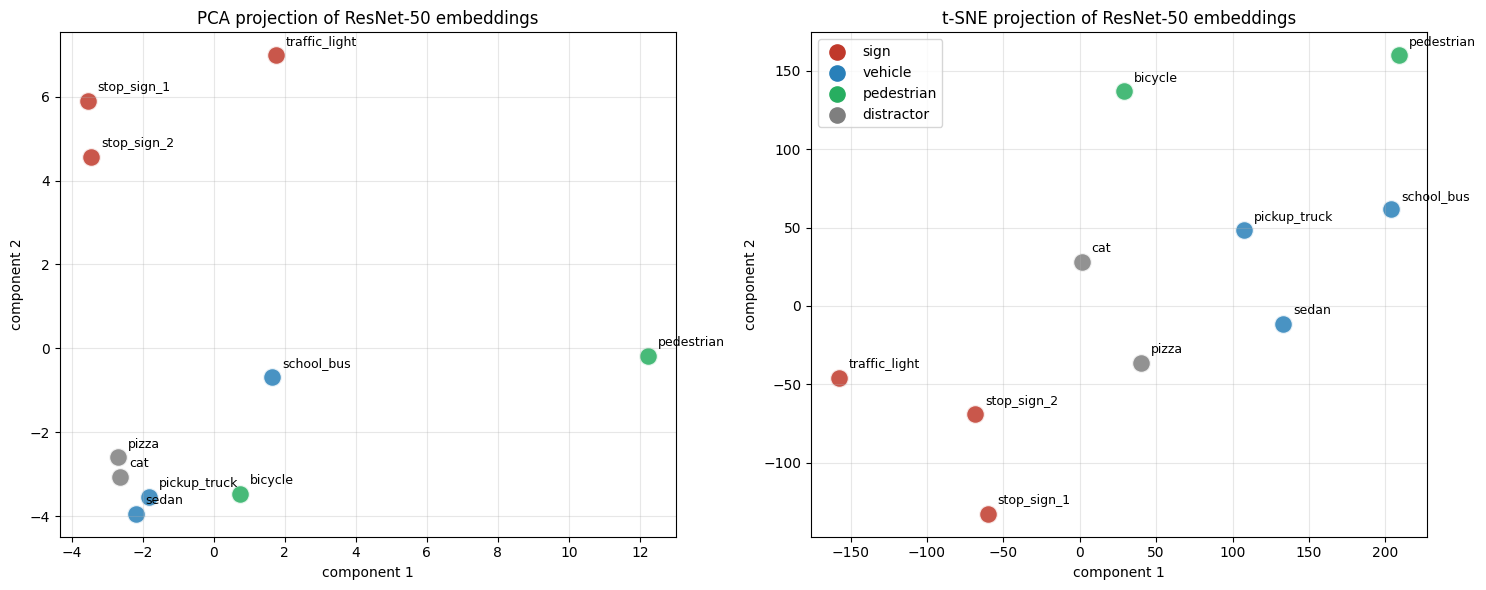

In [51]:
# Hand-assign categories so we can color the points
category = {
    'stop_sign_1': 'sign', 'stop_sign_2': 'sign', 'traffic_light': 'sign',
    'sedan': 'vehicle', 'pickup_truck': 'vehicle', 'school_bus': 'vehicle',
    'bicycle': 'pedestrian', 'pedestrian': 'pedestrian',
    'cat': 'distractor', 'pizza': 'distractor',
}
color_map = {'sign': '#c0392b', 'vehicle': '#2980b9', 'pedestrian': '#27ae60', 'distractor': '#7f7f7f'}
colors = [color_map[category.get(n, 'distractor')] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, coords, title in [(axes[0], emb_pca, 'PCA projection'),
                          (axes[1], emb_tsne, 't-SNE projection')]:
    for (x, y), c, n in zip(coords, colors, names):
        ax.scatter(x, y, color=c, s=180, alpha=0.85, edgecolors='white', linewidths=1.5)
        ax.annotate(n, (x, y), xytext=(7, 7), textcoords='offset points', fontsize=9)
    ax.set_title(f'{title} of ResNet-50 embeddings', fontsize=12)
    ax.set_xlabel('component 1')
    ax.set_ylabel('component 2')
    ax.grid(True, alpha=0.3)

# Legend
for cat, col in color_map.items():
    axes[1].scatter([], [], color=col, label=cat, s=120)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()


**What this shows visually:** the same clustering we measured numerically in the heatmap is now obvious geometrically. Signs sit together, vehicles sit together, pedestrians/bicycles sit together, and the distractors (cat, pizza) sit far from all of them.

Remember: those category labels (`sign`, `vehicle`, `pedestrian`) are **labels we assigned for plotting**. The CNN never saw them. The geometry was already there in the 2,048-dim embedding space — we just colored points by our human categories to *reveal* it.


## 9. Try It on Your Own Image

Want to see this on a real dashcam frame, a road-hazard photo, or any image you have? Drop a path or URL into the cell below and the same pipeline will produce its embedding and report which of the existing images it is most similar to. Useful for: building image retrieval systems, near-duplicate detection, or just sanity-checking whether your trained encoder generalizes to your data domain.


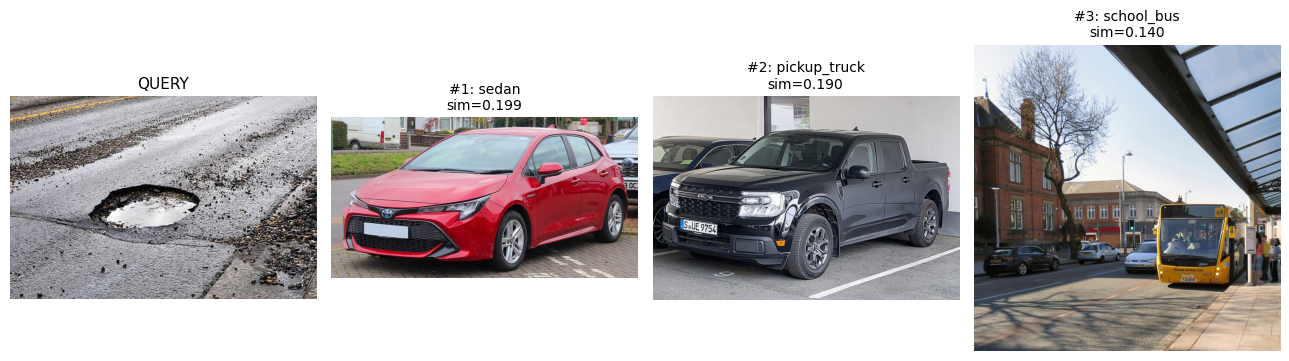

In [52]:
def embed_and_query(image_or_path):
    """Take a PIL image, file path, URL, or a 'commons:<File name>' shortcut; return its embedding and nearest neighbors among the demo set."""
    if isinstance(image_or_path, str):
        if image_or_path.startswith('commons:'):
            url = commons_thumb_url(image_or_path[len('commons:'):])
            r = requests.get(url, timeout=20, headers=headers)
            r.raise_for_status()
            img = Image.open(io.BytesIO(r.content)).convert('RGB')
        elif image_or_path.startswith('http'):
            r = requests.get(image_or_path, timeout=20, headers=headers)
            r.raise_for_status()
            img = Image.open(io.BytesIO(r.content)).convert('RGB')
        else:
            img = Image.open(image_or_path).convert('RGB')
    else:
        img = image_or_path.convert('RGB')

    # Re-register a hook just for avgpool (we removed earlier ones).
    # IMPORTANT: a forward hook must NOT return a value. If it does, PyTorch
    # uses that value as the layer's output and the next layer (here, fc) is
    # then handed a numpy array instead of a tensor and crashes. The earlier
    # version of this cell used `lambda ...: cap.setdefault('e', arr)`, which
    # silently returned `arr`. Use a named function with no return instead.
    cap = {}
    def grab(module, inp, out):
        cap['e'] = out.detach().cpu().squeeze().numpy()
    h = model.avgpool.register_forward_hook(grab)
    try:
        with torch.no_grad():
            _ = model(preprocess(img).unsqueeze(0).to(device))
    finally:
        h.remove()
    query_emb = cap['e']

    sims = cosine_similarity(query_emb.reshape(1, -1), embeddings)[0]
    order = np.argsort(-sims)

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
    axes[0].imshow(img); axes[0].set_title('QUERY', fontsize=11); axes[0].axis('off')
    for k in range(3):
        idx = order[k]
        axes[k+1].imshow(images[names[idx]])
        axes[k+1].set_title(f'#{k+1}: {names[idx]}\nsim={sims[idx]:.3f}', fontsize=10)
        axes[k+1].axis('off')
    plt.tight_layout(); plt.show()
    return query_emb, sims

# Example: query with the local pothole image. Replace with any local path,
# an http(s):// URL, or a 'commons:<File name>' shortcut to try your own.
_ = embed_and_query('./data/pothole.jpg')


If the pothole image's nearest neighbor in our small demo set turns out to be one of the road/vehicle images rather than the cat or pizza, that's a small piece of evidence that ResNet-50's embedding space is useful for road-condition tasks — even though ImageNet has no 'pothole' class.


## 10. Discussion Questions 

1. We used a ResNet-50 trained only on ImageNet's 1,000 categories — *none* of which is 'pothole', 'pedestrian crossing', or 'crash debris'. Yet the embeddings are clearly useful for organizing road-scene images. **Why does this work?**

2. If you wanted to adapt this network to specifically classify *road hazards on Florida highways*, what would you change? (Hint: think about which layers stay, which layers get replaced, and how much labeled data you'd need.)

3. Look back at the `layer4` feature maps. They are 7×7 in spatial resolution — much smaller than the input image. **Why is that information loss acceptable for classification but potentially a problem for tasks like pedestrian-bounding-box detection?**

4. The cosine similarity between the two stop signs is high — but not 1.0. **What kinds of variation are these embeddings invariant to, and what kinds are they not?** (Lighting, viewpoint, occlusion, weather.)

5. We used pooled global features (one vector per image). For tasks like dashcam object detection, we'd want **spatial** features. Where in this notebook would you change the pipeline to extract a *grid* of embeddings rather than one summary vector?

## Takeaways

- A classification CNN's penultimate layer is a powerful, general-purpose image encoder.
- Geometry in the embedding space corresponds to semantic similarity, even for categories the network was never trained on.
- This is the engine behind transfer learning, image retrieval, and zero-shot pipelines used in modern AI mobility systems.